# End-to-End Machine Learning Pipeline for Customer Churn Prediction

This project builds a machine learning pipeline to predict customer churn using the Telco Customer Churn dataset.

The pipeline includes:
- Data preprocessing
- Feature encoding
- Model training
Models compared:
- Model evaluation
- Visualization of results

- Logistic Regression
- Decision Tree
- Random Forest

## Load Dataset

In [95]:
import pandas as pd

data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Exploration

This step explores the structure and summary statistics of the dataset.

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [97]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

In this step, the dataset is cleaned to ensure data quality before training the machine learning models.

Actions performed:
- Removed the `customerID` column since it does not contribute to prediction.
- Converted the `TotalCharges` column to numeric format.
- Removed rows with missing values to avoid errors during model training.

In [98]:
data = data.drop("customerID", axis=1)

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

data = data.dropna()

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encoding Categorical Variables

Machine learning models require numerical input.  
Categorical variables are converted into numerical values using Label Encoding.

In [99]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in data.columns:
    if data[column].dtype == "object":
        data[column] = le.fit_transform(data[column])

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## Feature and Target Variables

The dataset is separated into input features (X) and the target variable (y).

- **X** contains all customer attributes used for prediction.
- **y** represents the churn status that the model will learn to predict.

In [100]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

## Train-Test Split

The dataset is divided into training and testing sets.

- Training data (80%) is used to train the model.
- Testing data (20%) is used to evaluate model performance.

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training - Logistic Regression

A Logistic Regression model is trained to predict whether a customer will churn based on the available features.

Logistic Regression is commonly used for binary classification problems such as churn prediction.

In [102]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


## Model Prediction

After training the model, predictions are generated using the test dataset to evaluate how well the model generalizes to unseen data.

In [103]:
y_pred = model.predict(X_test)

## Model Evaluation

Model performance is evaluated using accuracy score, which measures the proportion of correct predictions made by the model.

In [104]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7853589196872779


## Confusion Matrix

The confusion matrix provides a detailed view of model prediction performance.

It shows:
- **True Positives (TP)** – correctly predicted churn
- **True Negatives (TN)** – correctly predicted non-churn
- **False Positives (FP)** – predicted churn but actually not
- **False Negatives (FN)** – predicted non-churn but actually churn

This helps evaluate how well the model distinguishes between churn and non-churn customers.

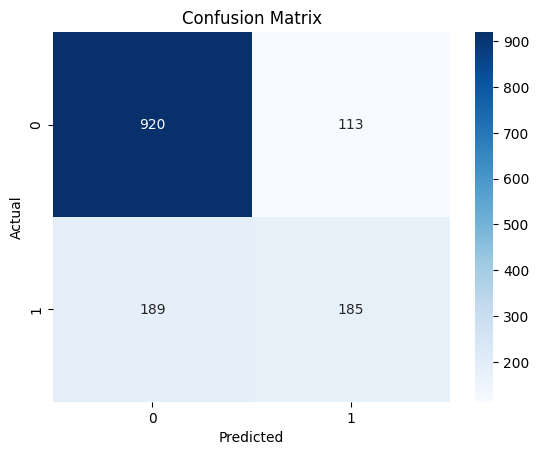

In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

This model is commonly used for classification tasks because it captures complex relationships within the data.

In [106]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7825159914712153


## Decision Tree Model

Decision Tree is a supervised machine learning algorithm that makes predictions by learning decision rules derived from the data features.

Although simple, it provides interpretable results and can capture non-linear relationships.

In [107]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7292110874200426


### Accuracy Comparison Between Models

To evaluate which algorithm performs best, the accuracy scores of the three models are calculated:

- Logistic Regression
- Random Forest
- Decision Tree

The results provide a quantitative comparison of model performance before visualizing them in the next step.

In [108]:
log_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, rf_pred)
dt_acc = accuracy_score(y_test, dt_pred)

print("Logistic Regression:", log_acc)
print("Random Forest:", rf_acc)
print("Decision Tree:", dt_acc)

Logistic Regression: 0.7853589196872779
Random Forest: 0.7825159914712153
Decision Tree: 0.7292110874200426


## Model Performance Comparison

To determine the best performing model, the accuracy scores of Logistic Regression, Random Forest, and Decision Tree are compared.

The visualization below illustrates how each model performs on the same dataset.

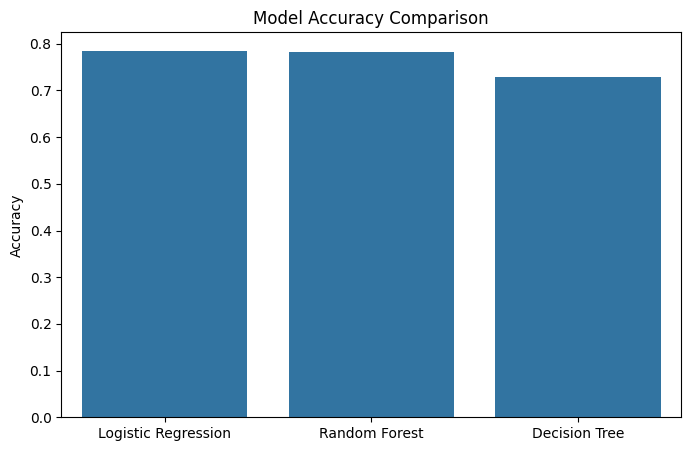

In [109]:
models = ["Logistic Regression", "Random Forest", "Decision Tree"]
scores = [log_acc, rf_acc, dt_acc]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

## ROC Curve Analysis

The ROC (Receiver Operating Characteristic) curve evaluates the classification performance across different thresholds.

The **AUC (Area Under the Curve)** represents the model's ability to distinguish between churn and non-churn customers.

A higher AUC score indicates better model performance.

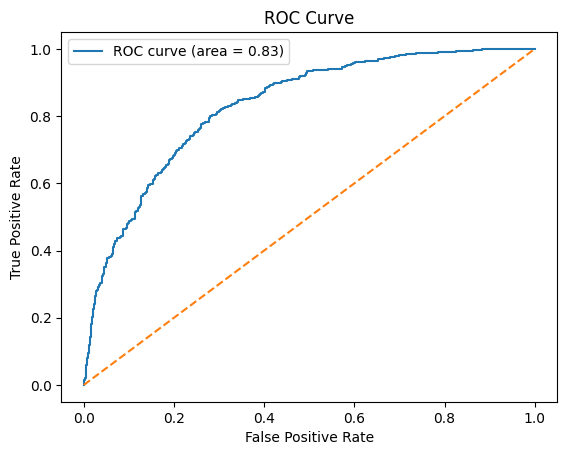

In [110]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Feature Importance Analysis

To better understand which factors influence customer churn, feature importance analysis is performed using the Random Forest model.

Feature importance indicates how much each variable contributes to the prediction of churn.

By analyzing the most influential features, we can identify key drivers of customer behavior and potential risk factors for churn.

In [111]:
feature_importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
18,TotalCharges,0.184743
17,MonthlyCharges,0.180089
4,tenure,0.153534
14,Contract,0.084543
8,OnlineSecurity,0.050893
16,PaymentMethod,0.050184
11,TechSupport,0.042834
7,InternetService,0.028443
0,gender,0.028027
15,PaperlessBilling,0.025206


### Top 10 Most Important Features

The visualization below highlights the top features that have the strongest impact on predicting customer churn.

From the analysis, financial and engagement-related variables such as **TotalCharges**, **MonthlyCharges**, and **tenure** appear to be the most influential predictors.

Understanding these factors can help companies design strategies to improve customer retention.

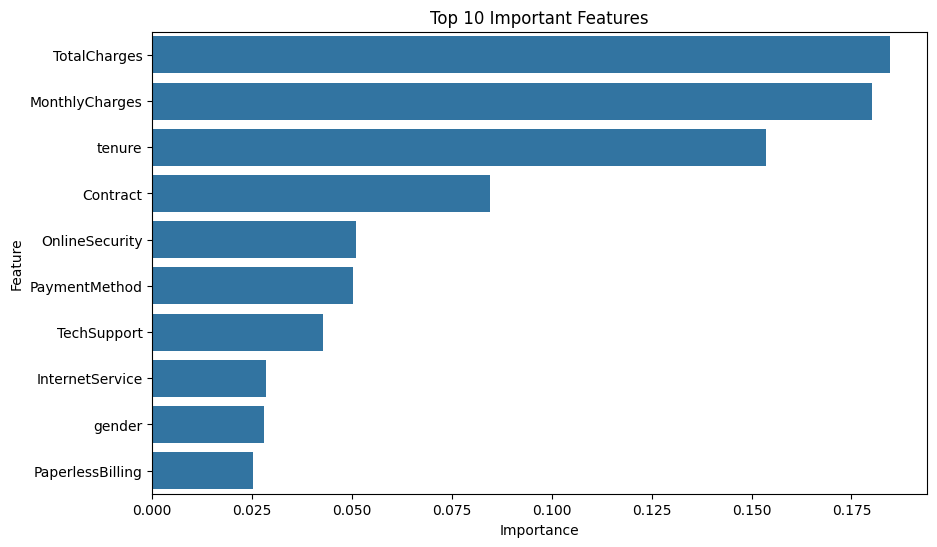

In [112]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

## Key Insights

From the feature importance analysis:

- TotalCharges and MonthlyCharges are strong predictors of churn
- Customers with higher monthly costs may have a greater risk of leaving
- Tenure plays an important role, indicating newer customers are more likely to churn
- Service features like OnlineSecurity and TechSupport also influence churn

These insights can help companies identify at-risk customers and develop retention strategies.

## Conclusion

Logistic Regression and Random Forest achieved similar accuracy (~0.78),
while Decision Tree showed lower performance.

Feature importance analysis indicates that TotalCharges, MonthlyCharges,
and tenure are the most influential factors in predicting customer churn.

These insights can help businesses identify high-risk customers and
design targeted retention strategies.